# In-Class Exercise (Due Feb 6th)

1. Download the Manhattan house price data from Canvas. This dataset includes house transaction data from Manhattan from 2011 to 2017 - bring in the entire folder into your current working directory. 

!pip install openpyxl --upgrade --pre

In [1]:
import pandas as pd

/Users/yujinlee/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
# First, let's check our current working directory 

import os 
os.getcwd()

'/Users/yujinlee/Documents/Spring 2026/CRP 5680/Discussion'

In [80]:
# if you want to change your working directory any time in the future 

os.chdir('/Users/yujinlee/Documents/Spring 2026/CRP 5680/Class Material')


In [4]:
## if the name of the columns match, let's concatenate them 

df_combine = pd.DataFrame()

for year in list(range(2011, 2018)):
    df_temp = pd.read_excel(str(year) +  "_manhattan.xlsx")
    if year == 2011:
        df_combine = df_temp
    else: 
        if list(df_combine.columns) == list(df_temp.columns):
            print("columns match")
            df_combine = pd.concat([df_combine, df_temp])
        else: 
            print("columns do not match")
df_combine

columns match
columns match
columns match
columns match
columns match
columns match


,BOROUGH,NEIGHBORHOOD,BUILDING CLASS CATEGORY,TAX CLASS AT PRESENT,BLOCK,LOT,EASE-MENT,BUILDING CLASS AT PRESENT,ADDRESS,APARTMENT NUMBER,...,RESIDENTIAL UNITS,COMMERCIAL UNITS,TOTAL UNITS,LAND SQUARE FEET,GROSS SQUARE FEET,YEAR BUILT,TAX CLASS AT TIME OF SALE,BUILDING CLASS AT TIME OF SALE,SALE PRICE,SALE DATE
0,1,ALPHABET CITY,01 ONE FAMILY HOMES,1,376,43,,S1,743 EAST 6TH STREET,,...,1,1,2,2090,3680,1940,1,S1,10,2011-08-26
1,1,ALPHABET CITY,02 TWO FAMILY HOMES,1,373,1,,S2,40 AVENUE C,,...,2,1,3,1923,4800,1901,1,S2,0,2011-12-21
2,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2A,372,31,,C3,316 EAST 3RD STREET,,...,4,0,4,5746,2700,1900,2,C3,3500000,2011-09-08
3,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2,376,54,,C4,719 E 6TH ST,,...,16,0,16,3437,9180,1900,2,C4,2966835,2011-07-25
4,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2,377,2,,C7,116 AVENUE C,,...,22,3,25,4510,19830,1900,2,C7,0,2011-06-10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18637,1,WASHINGTON HEIGHTS UPPER,32 HOSPITAL AND HEALTH FACILITIES,4,2152,47,,I9,2414 AMSTERDAM AVENUE,,...,0,3,3,2500,3350,1902,4,I9,1375000,2017-12-08
18638,1,WASHINGTON HEIGHTS UPPER,33 EDUCATIONAL FACILITIES,4,2149,23,,W2,2495 AMSTERDAM AVENUE,,...,0,1,1,29775,253942,1969,4,W2,0,2017-04-21
18639,1,WASHINGTON HEIGHTS UPPER,33 EDUCATIONAL FACILITIES,4,2156,48,,W6,2520 AMSTERDAM AVENUE,,...,0,1,1,25875,140260,1967,4,W6,0,2017-04-21
18640,1,WASHINGTON HEIGHTS UPPER,33 EDUCATIONAL FACILITIES,4,2156,61,,W6,515 WEST 185 STREET,,...,0,1,1,2700,16262,2007,4,W6,0,2017-08-23


In [5]:
## can we see the columns of the dataframe

df_combine.columns[0]

'BOROUGH'

In [6]:
## how about the number of rows and columns? (rows, columns) format

df_combine.shape

(163869, 21)

In [7]:
## how about the data types of the columns? 

df_combine.dtypes

BOROUGH                                    int64
NEIGHBORHOOD                              object
BUILDING CLASS CATEGORY                   object
TAX CLASS AT PRESENT                      object
BLOCK                                      int64
LOT                                        int64
EASE-MENT                                 object
BUILDING CLASS AT PRESENT                 object
ADDRESS                                   object
APARTMENT NUMBER                          object
ZIP CODE                                   int64
RESIDENTIAL UNITS                          int64
COMMERCIAL UNITS                           int64
TOTAL UNITS                                int64
LAND SQUARE FEET                           int64
GROSS SQUARE FEET                          int64
YEAR BUILT                                 int64
TAX CLASS AT TIME OF SALE                  int64
BUILDING CLASS AT TIME OF SALE            object
SALE PRICE                                 int64
SALE DATE           

In [8]:
df_combine['BLOCK'] = df_combine['BLOCK'].astype('int')

In [9]:
df_combine.dtypes

BOROUGH                                    int64
NEIGHBORHOOD                              object
BUILDING CLASS CATEGORY                   object
TAX CLASS AT PRESENT                      object
BLOCK                                      int64
LOT                                        int64
EASE-MENT                                 object
BUILDING CLASS AT PRESENT                 object
ADDRESS                                   object
APARTMENT NUMBER                          object
ZIP CODE                                   int64
RESIDENTIAL UNITS                          int64
COMMERCIAL UNITS                           int64
TOTAL UNITS                                int64
LAND SQUARE FEET                           int64
GROSS SQUARE FEET                          int64
YEAR BUILT                                 int64
TAX CLASS AT TIME OF SALE                  int64
BUILDING CLASS AT TIME OF SALE            object
SALE PRICE                                 int64
SALE DATE           

In [10]:
## try looking at the first row value of each colun with the .iloc format

df_combine.iloc[0]

BOROUGH                                                                      1
NEIGHBORHOOD                                         ALPHABET CITY            
BUILDING CLASS CATEGORY           01  ONE FAMILY HOMES                        
TAX CLASS AT PRESENT                                                         1
BLOCK                                                                      376
LOT                                                                         43
EASE-MENT                                                                     
BUILDING CLASS AT PRESENT                                                   S1
ADDRESS                              743 EAST 6TH   STREET                    
APARTMENT NUMBER                                                              
ZIP CODE                                                                 10009
RESIDENTIAL UNITS                                                            1
COMMERCIAL UNITS                                    

## Good to know! loc vs iloc

* df.loc[ *rows* , *columns* ] - loc function is **inclusive** of the last value. 
<br>For example, df.loc[2:4 , df.columns[3:5]] would show rows indexed 2-4, and columns indexed 3-5 

* df.iloc[ *rows*, *columns* ] - iloc function is **exclusive** of the last value.
<br>For example, df.iloc[2:4 , 3:5] would show rows indexed 2-3, and columns indexed 3-4

* fyi, range() is also **exclusive** of the last value.

In [11]:
# select the last two rows and the last three columns using df.loc[]

df_combine.loc[ df_combine.index[-2: ], df_combine.columns[-3: ]]

,BUILDING CLASS AT TIME OF SALE,SALE PRICE,SALE DATE
18640,D4,1625000,2011-02-15
18640,D4,2100000,2012-04-20
18640,D4,2110000,2013-05-14
18640,R9,360000,2014-10-17
18640,R9,435704,2015-07-31
18640,R4,40000,2016-02-16
18640,W6,0,2017-08-23
18641,D4,0,2011-01-14
18641,D4,1805000,2012-05-18
18641,D4,845000,2013-05-28


In [12]:
# I asked for the last two rows, but I got 14 rows. Why is that?
# How should we trouble shoot?

In [13]:
df_combine2 = df_combine

In [14]:
df_combine2.reset_index()

,index,BOROUGH,NEIGHBORHOOD,BUILDING CLASS CATEGORY,TAX CLASS AT PRESENT,BLOCK,LOT,EASE-MENT,BUILDING CLASS AT PRESENT,ADDRESS,...,RESIDENTIAL UNITS,COMMERCIAL UNITS,TOTAL UNITS,LAND SQUARE FEET,GROSS SQUARE FEET,YEAR BUILT,TAX CLASS AT TIME OF SALE,BUILDING CLASS AT TIME OF SALE,SALE PRICE,SALE DATE
0,0,1,ALPHABET CITY,01 ONE FAMILY HOMES,1,376,43,,S1,743 EAST 6TH STREET,...,1,1,2,2090,3680,1940,1,S1,10,2011-08-26
1,1,1,ALPHABET CITY,02 TWO FAMILY HOMES,1,373,1,,S2,40 AVENUE C,...,2,1,3,1923,4800,1901,1,S2,0,2011-12-21
2,2,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2A,372,31,,C3,316 EAST 3RD STREET,...,4,0,4,5746,2700,1900,2,C3,3500000,2011-09-08
3,3,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2,376,54,,C4,719 E 6TH ST,...,16,0,16,3437,9180,1900,2,C4,2966835,2011-07-25
4,4,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2,377,2,,C7,116 AVENUE C,...,22,3,25,4510,19830,1900,2,C7,0,2011-06-10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
163864,18637,1,WASHINGTON HEIGHTS UPPER,32 HOSPITAL AND HEALTH FACILITIES,4,2152,47,,I9,2414 AMSTERDAM AVENUE,...,0,3,3,2500,3350,1902,4,I9,1375000,2017-12-08
163865,18638,1,WASHINGTON HEIGHTS UPPER,33 EDUCATIONAL FACILITIES,4,2149,23,,W2,2495 AMSTERDAM AVENUE,...,0,1,1,29775,253942,1969,4,W2,0,2017-04-21
163866,18639,1,WASHINGTON HEIGHTS UPPER,33 EDUCATIONAL FACILITIES,4,2156,48,,W6,2520 AMSTERDAM AVENUE,...,0,1,1,25875,140260,1967,4,W6,0,2017-04-21
163867,18640,1,WASHINGTON HEIGHTS UPPER,33 EDUCATIONAL FACILITIES,4,2156,61,,W6,515 WEST 185 STREET,...,0,1,1,2700,16262,2007,4,W6,0,2017-08-23


In [15]:
# what happens if we run the code again?

#solution 1
df_combine.reset_index(drop = True).loc[ df_combine.index[-2: ], df_combine.columns[-3: ]]

#solution 2 
df_reset = df_combine.reset_index(drop= True)
df_reset.loc[df_reset.index[-2: ], df_reset.columns[-3: ]]

,BUILDING CLASS AT TIME OF SALE,SALE PRICE,SALE DATE
163867,W6,0,2017-08-23
163868,N2,1100000,2017-09-07


In [16]:
# what if we only want to see the first three rows and the columns "ZIP CODE", "TOTAL UNITS", "YEAR BUILT" 

## using df.loc[]
df_reset.loc[0:2, ['ZIP CODE', 'TOTAL UNITS', 'YEAR BUILT']]

## solution #2
df_reset.loc[df_reset.index[:3], ['ZIP CODE', 'TOTAL UNITS', 'YEAR BUILT']]


,ZIP CODE,TOTAL UNITS,YEAR BUILT
0,10009,2,1940
1,10009,3,1901
2,10009,4,1900


In [17]:
## using df.iloc[]

df_reset.iloc[ :3, [list(df_reset.columns).index("ZIP CODE"), list(df_reset.columns).index("TOTAL UNITS"),
                     list(df_reset.columns).index("YEAR BUILT")]]

,ZIP CODE,TOTAL UNITS,YEAR BUILT
0,10009,2,1940
1,10009,3,1901
2,10009,4,1900


In [18]:
list(df_reset.columns)

['BOROUGH',
 'NEIGHBORHOOD',
 'BUILDING CLASS CATEGORY',
 'TAX CLASS AT PRESENT',
 'BLOCK',
 'LOT',
 'EASE-MENT',
 'BUILDING CLASS AT PRESENT',
 'ADDRESS',
 'APARTMENT NUMBER',
 'ZIP CODE',
 'RESIDENTIAL UNITS',
 'COMMERCIAL UNITS',
 'TOTAL UNITS',
 'LAND SQUARE FEET',
 'GROSS SQUARE FEET',
 'YEAR BUILT',
 'TAX CLASS AT TIME OF SALE',
 'BUILDING CLASS AT TIME OF SALE',
 'SALE PRICE',
 'SALE DATE']

In [19]:
## How many columns and rows would you expect to see from the commands below?
df_reset.iloc[2:4, 0:3]

,BOROUGH,NEIGHBORHOOD,BUILDING CLASS CATEGORY
2,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS
3,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS


In [20]:
df_reset.loc[2:4, df_reset.columns[0:3]]

,BOROUGH,NEIGHBORHOOD,BUILDING CLASS CATEGORY
2,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS
3,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS
4,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS


## Exercise 1

The basics for any data management starts with data cleaning. 
<br>Is there any NA values, or wierd values that we see?

In [21]:
df_reset.describe()

,BOROUGH,BLOCK,LOT,ZIP CODE,RESIDENTIAL UNITS,COMMERCIAL UNITS,TOTAL UNITS,LAND SQUARE FEET,GROSS SQUARE FEET,YEAR BUILT,TAX CLASS AT TIME OF SALE,SALE PRICE,SALE DATE
count,163869.0,163869.000000,163869.000000,163869.000000,163869.000000,163869.000000,163869.000000,1.638690e+05,1.638690e+05,163869.000000,163869.000000,1.638690e+05,163869
mean,1.0,1106.202479,754.469784,10005.085880,2.071362,0.423479,2.604556,1.137799e+03,9.733637e+03,1619.092763,2.419683,2.333295e+06,2014-05-22 01:26:39.743697664
min,1.0,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,1.000000,0.000000e+00,2011-01-01 00:00:00
25%,1.0,859.000000,36.000000,10016.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,1909.000000,2.000000,2.000000e+02,2012-10-22 00:00:00
50%,1.0,1048.000000,1004.000000,10019.000000,0.000000,0.000000,1.000000,0.000000e+00,0.000000e+00,1931.000000,2.000000,5.650000e+05,2014-04-22 00:00:00
75%,1.0,1417.000000,1234.000000,10027.000000,1.000000,0.000000,1.000000,0.000000e+00,0.000000e+00,1977.000000,2.000000,1.400000e+06,2015-12-15 00:00:00
max,1.0,2255.000000,9139.000000,10463.000000,8759.000000,2000.000000,8805.000000,1.132000e+07,8.942176e+06,2017.000000,4.000000,4.111112e+09,2017-12-31 00:00:00
std,0.0,488.425949,869.991962,495.062214,36.633639,7.143693,37.520546,3.565805e+04,5.714796e+04,737.419571,0.845355,2.460882e+07,NaN


In [22]:
df_reset[df_reset['ZIP CODE'] ==0]

,BOROUGH,NEIGHBORHOOD,BUILDING CLASS CATEGORY,TAX CLASS AT PRESENT,BLOCK,LOT,EASE-MENT,BUILDING CLASS AT PRESENT,ADDRESS,APARTMENT NUMBER,...,RESIDENTIAL UNITS,COMMERCIAL UNITS,TOTAL UNITS,LAND SQUARE FEET,GROSS SQUARE FEET,YEAR BUILT,TAX CLASS AT TIME OF SALE,BUILDING CLASS AT TIME OF SALE,SALE PRICE,SALE DATE
28874,1,JAVITS CENTER,31 COMMERCIAL VACANT LAND,4,665,11,,V1,12TH AVENUE,,...,0,0,0,43954,0,0,4,V1,7500000,2012-05-08
55278,1,KIPS BAY,31 COMMERCIAL VACANT LAND,4,967,1,,V1,1 AVENUE,,...,0,0,0,45190,0,0,4,V1,172125000,2013-02-04
80776,1,HARLEM-CENTRAL,31 COMMERCIAL VACANT LAND,4,1920,53,,V1,WEST 136 STREET,,...,0,0,0,1665,0,0,4,V1,86000,2014-08-13
118095,1,UPPER EAST SIDE (59-79),29 COMMERCIAL GARAGES,4,1435,15,,G6,321-323 EAST 60TH STREET,,...,0,0,0,3749,0,0,4,G6,12000000,2015-06-30
121691,1,UPPER WEST SIDE (59-79),31 COMMERCIAL VACANT LAND,4,1171,151,,V1,JOE DIMAGGIO HIGHWAY,,...,0,0,0,29638,0,0,4,V1,25000000,2015-08-20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
161735,1,UPPER WEST SIDE (59-79),13 CONDOS - ELEVATOR APARTMENTS,,1171,4738,,,1 WEST END AVENUE,,...,0,0,0,0,0,0,2,R4,3246434,2017-09-05
162691,1,UPPER WEST SIDE (79-96),13 CONDOS - ELEVATOR APARTMENTS,,1209,1343,,,360 CENTRAL PARK WEST,,...,0,0,0,0,0,0,2,R4,1299287,2017-11-29
162693,1,UPPER WEST SIDE (79-96),13 CONDOS - ELEVATOR APARTMENTS,,1209,1398,,,360 CENTRAL PARK WEST,,...,0,0,0,0,0,0,2,R4,5656378,2017-12-20
163031,1,UPPER WEST SIDE (79-96),15 CONDOS - 2-10 UNIT RESIDENTIAL,,1233,1305,,,272 WEST 86TH STREET,,...,0,0,0,0,0,0,2,R1,4582125,2017-11-07


In [23]:
df_reset[df_reset['SALE PRICE']==0]

,BOROUGH,NEIGHBORHOOD,BUILDING CLASS CATEGORY,TAX CLASS AT PRESENT,BLOCK,LOT,EASE-MENT,BUILDING CLASS AT PRESENT,ADDRESS,APARTMENT NUMBER,...,RESIDENTIAL UNITS,COMMERCIAL UNITS,TOTAL UNITS,LAND SQUARE FEET,GROSS SQUARE FEET,YEAR BUILT,TAX CLASS AT TIME OF SALE,BUILDING CLASS AT TIME OF SALE,SALE PRICE,SALE DATE
1,1,ALPHABET CITY,02 TWO FAMILY HOMES,1,373,1,,S2,40 AVENUE C,,...,2,1,3,1923,4800,1901,1,S2,0,2011-12-21
4,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2,377,2,,C7,116 AVENUE C,,...,22,3,25,4510,19830,1900,2,C7,0,2011-06-10
5,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2B,384,17,,C4,225 EAST 2ND STREET,,...,10,0,10,2145,6670,1900,2,C4,0,2011-11-03
6,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2B,384,18,,C4,227 EAST 2ND STREET,,...,10,0,10,2100,6525,1900,2,C4,0,2011-11-03
13,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2,398,26,,C1,192 EAST 3RD STREET,,...,20,0,20,2568,9270,1900,2,C1,0,2011-12-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
163860,1,WASHINGTON HEIGHTS UPPER,14 RENTALS - 4-10 UNIT,2A,2154,88,,S9,551 WEST 183RD STREET,,...,2,3,5,1873,3746,1915,2,S9,0,2017-06-26
163862,1,WASHINGTON HEIGHTS UPPER,22 STORE BUILDINGS,4,2170,59,,K2,4446 BROADWAY,,...,0,4,4,10675,9900,1930,4,K2,0,2017-08-16
163865,1,WASHINGTON HEIGHTS UPPER,33 EDUCATIONAL FACILITIES,4,2149,23,,W2,2495 AMSTERDAM AVENUE,,...,0,1,1,29775,253942,1969,4,W2,0,2017-04-21
163866,1,WASHINGTON HEIGHTS UPPER,33 EDUCATIONAL FACILITIES,4,2156,48,,W6,2520 AMSTERDAM AVENUE,,...,0,1,1,25875,140260,1967,4,W6,0,2017-04-21


In [24]:
df_price = df_reset.loc[df_reset['SALE PRICE'] != 0]
df_price

,BOROUGH,NEIGHBORHOOD,BUILDING CLASS CATEGORY,TAX CLASS AT PRESENT,BLOCK,LOT,EASE-MENT,BUILDING CLASS AT PRESENT,ADDRESS,APARTMENT NUMBER,...,RESIDENTIAL UNITS,COMMERCIAL UNITS,TOTAL UNITS,LAND SQUARE FEET,GROSS SQUARE FEET,YEAR BUILT,TAX CLASS AT TIME OF SALE,BUILDING CLASS AT TIME OF SALE,SALE PRICE,SALE DATE
0,1,ALPHABET CITY,01 ONE FAMILY HOMES,1,376,43,,S1,743 EAST 6TH STREET,,...,1,1,2,2090,3680,1940,1,S1,10,2011-08-26
2,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2A,372,31,,C3,316 EAST 3RD STREET,,...,4,0,4,5746,2700,1900,2,C3,3500000,2011-09-08
3,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2,376,54,,C4,719 E 6TH ST,,...,16,0,16,3437,9180,1900,2,C4,2966835,2011-07-25
7,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2B,384,26,,C4,243 EAST 2ND STREET,,...,10,0,10,1600,7060,1900,2,C4,1400000,2011-01-31
8,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2B,384,27,,C4,245 EAST 2ND STREET,,...,10,0,10,1600,6950,1900,2,C4,800000,2011-01-31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
163859,1,WASHINGTON HEIGHTS UPPER,13 CONDOS - ELEVATOR APARTMENTS,2,2180,1565,,R4,105 BENNETT AVENUE,12HB,...,1,0,1,0,0,1939,2,R4,400530,2017-01-26
163861,1,WASHINGTON HEIGHTS UPPER,22 STORE BUILDINGS,4,2158,65,,K1,1588 ST NICHOLAS AVENUE,,...,0,4,4,4488,4991,1960,4,K1,2375000,2017-12-29
163863,1,WASHINGTON HEIGHTS UPPER,31 COMMERCIAL VACANT LAND,4,2179,474,,V1,CHITTENDEN AVENUE,,...,0,0,0,11000,0,0,4,V1,563400,2017-10-24
163864,1,WASHINGTON HEIGHTS UPPER,32 HOSPITAL AND HEALTH FACILITIES,4,2152,47,,I9,2414 AMSTERDAM AVENUE,,...,0,3,3,2500,3350,1902,4,I9,1375000,2017-12-08


In [25]:
df_zip = df_price.loc[df_price['ZIP CODE'] != 0]
df_zip

,BOROUGH,NEIGHBORHOOD,BUILDING CLASS CATEGORY,TAX CLASS AT PRESENT,BLOCK,LOT,EASE-MENT,BUILDING CLASS AT PRESENT,ADDRESS,APARTMENT NUMBER,...,RESIDENTIAL UNITS,COMMERCIAL UNITS,TOTAL UNITS,LAND SQUARE FEET,GROSS SQUARE FEET,YEAR BUILT,TAX CLASS AT TIME OF SALE,BUILDING CLASS AT TIME OF SALE,SALE PRICE,SALE DATE
0,1,ALPHABET CITY,01 ONE FAMILY HOMES,1,376,43,,S1,743 EAST 6TH STREET,,...,1,1,2,2090,3680,1940,1,S1,10,2011-08-26
2,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2A,372,31,,C3,316 EAST 3RD STREET,,...,4,0,4,5746,2700,1900,2,C3,3500000,2011-09-08
3,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2,376,54,,C4,719 E 6TH ST,,...,16,0,16,3437,9180,1900,2,C4,2966835,2011-07-25
7,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2B,384,26,,C4,243 EAST 2ND STREET,,...,10,0,10,1600,7060,1900,2,C4,1400000,2011-01-31
8,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2B,384,27,,C4,245 EAST 2ND STREET,,...,10,0,10,1600,6950,1900,2,C4,800000,2011-01-31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
163858,1,WASHINGTON HEIGHTS UPPER,13 CONDOS - ELEVATOR APARTMENTS,2,2180,1559,,R4,105 BENNETT AVENUE,64A,...,1,0,1,0,0,1939,2,R4,475000,2017-01-05
163859,1,WASHINGTON HEIGHTS UPPER,13 CONDOS - ELEVATOR APARTMENTS,2,2180,1565,,R4,105 BENNETT AVENUE,12HB,...,1,0,1,0,0,1939,2,R4,400530,2017-01-26
163861,1,WASHINGTON HEIGHTS UPPER,22 STORE BUILDINGS,4,2158,65,,K1,1588 ST NICHOLAS AVENUE,,...,0,4,4,4488,4991,1960,4,K1,2375000,2017-12-29
163864,1,WASHINGTON HEIGHTS UPPER,32 HOSPITAL AND HEALTH FACILITIES,4,2152,47,,I9,2414 AMSTERDAM AVENUE,,...,0,3,3,2500,3350,1902,4,I9,1375000,2017-12-08


In [26]:
df_final = df_reset[(df_reset['ZIP CODE'] != 0) & (df_reset['SALE PRICE'] != 0)]

## Exercise 2

Currently we have the column 'SALE DATE' in YYYY-MM-DD format. 
<Br>After creating a separate column named 'Year' with only the years, find the average sales price per year. 
<br>Lastly, make a line plot that displays the average sales price per year

import warnings
warnings.filterwarnings("ignore")

In [28]:
df_zip['YEAR'] = df_zip['SALE DATE'].dt.year

In [29]:
df_zip['YEAR2'] = df_zip['SALE DATE'].apply(lambda x: x.year)

In [30]:
df_zip['YEAR2'] = '.' 

for idx, row in df_zip.iterrows():
    df_zip.loc[idx, 'YEAR2'] = row['SALE DATE'].year

In [31]:
df_zip.groupby(by= 'YEAR')[['SALE PRICE']].mean()

,SALE PRICE
YEAR,
2011,2.183259e+06
2012,2.477635e+06
2013,2.590772e+06
2014,3.495065e+06
2015,3.732717e+06
2016,3.634643e+06
2017,3.184740e+06


In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df_zip['SALE PRICE'].describe()

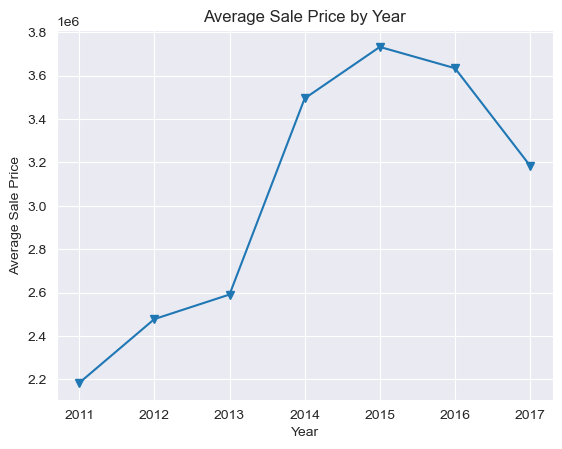

In [34]:
sns.set_style('darkgrid')

df_zip.groupby('YEAR')['SALE PRICE'].mean().plot(marker='v')

plt.xlabel("Year")
plt.ylabel("Average Sale Price")
plt.title("Average Sale Price by Year")
plt.show()

## whitegrid, darkgrid, white, dark, ticks

## Exercise 3

But wait! Did we check the univariate plots of the Sale Prices? 
<br>Try getting rid of outliers and replotting the graph - put the plots side by side with each other

<Axes: ylabel='Frequency'>

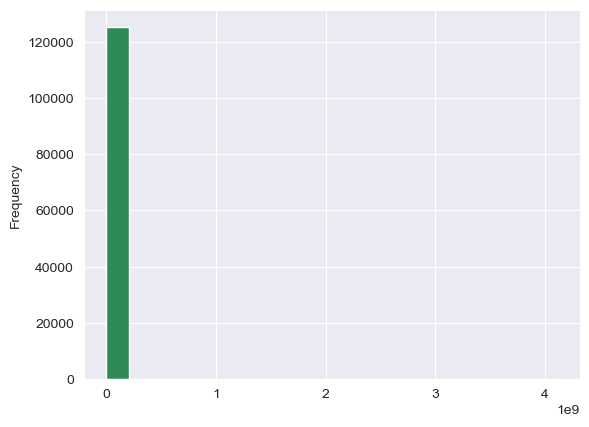

In [35]:
df_zip['SALE PRICE'].plot(kind = 'hist', 
                          orientation = 'vertical',
                          cumulative = False,
                          bins = 20,
                         color = 'seagreen')

In [36]:
## We would define an outlier noramlly with values beyond 3 standard deviations 

mean_price = df_zip['SALE PRICE'].mean()
std_price = df_zip['SALE PRICE'].std()

## Create an equation to identify outliers

df_outliers = df_zip[df_zip['SALE PRICE'] > mean_price + 3 * std_price]


In [37]:
## What would a dataframe without the outliers look like?

df_final = df_zip[df_zip['SALE PRICE'] <= mean_price + 3 * std_price]

Text(0.02, 0.5, 'Average Sale Price')

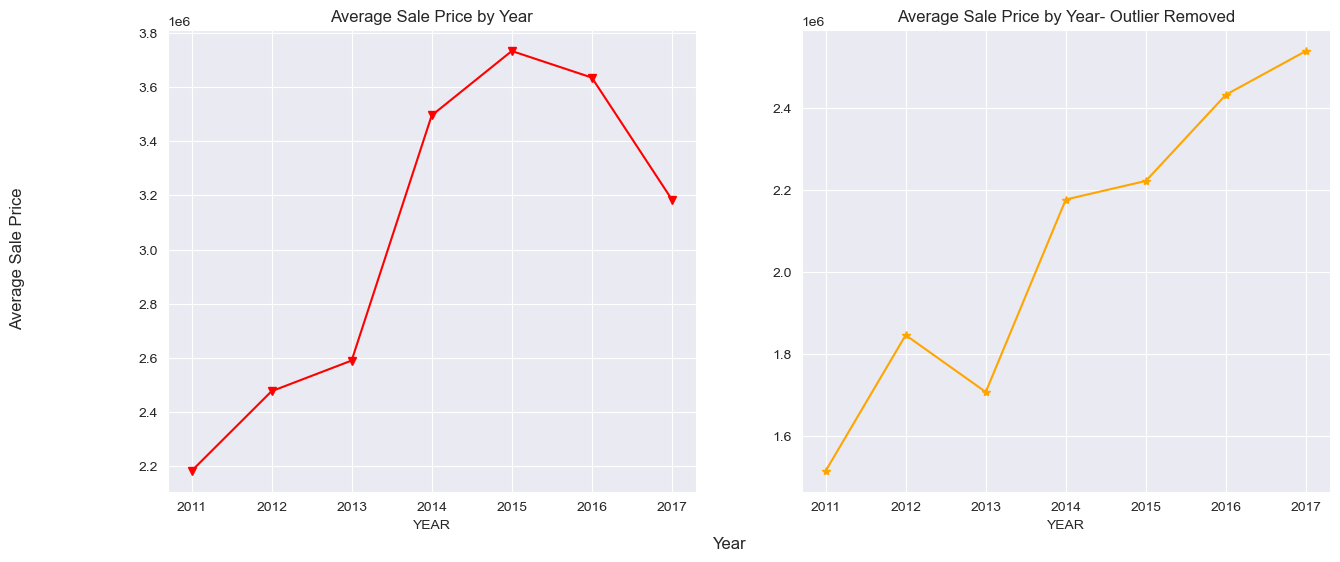

In [38]:
fig, ax = plt.subplots(1,2, figsize = (15, 6))

df_zip.groupby('YEAR')['SALE PRICE'].mean().plot(marker='v',
                                                 color = 'red',
                                                 ax = ax[0])
ax[0].set_title("Average Sale Price by Year")

df_final.groupby('YEAR')['SALE PRICE'].mean().plot(marker='*',
                                                   color = 'orange',
                                                   ax = ax[1])
ax[1].set_title("Average Sale Price by Year- Outlier Removed")

fig.supxlabel("Year")
fig.supylabel("Average Sale Price")

We can also change the style of the plotting:

- `plt.style.use('default')`: this is the matplotlib default
- `plt.style.use('seaborn-darkgrid')`: seaborn-darkgrid style
- `plt.style.use('ggplot')`: ggplot style

Text(0.02, 0.5, 'Average Sale Price')

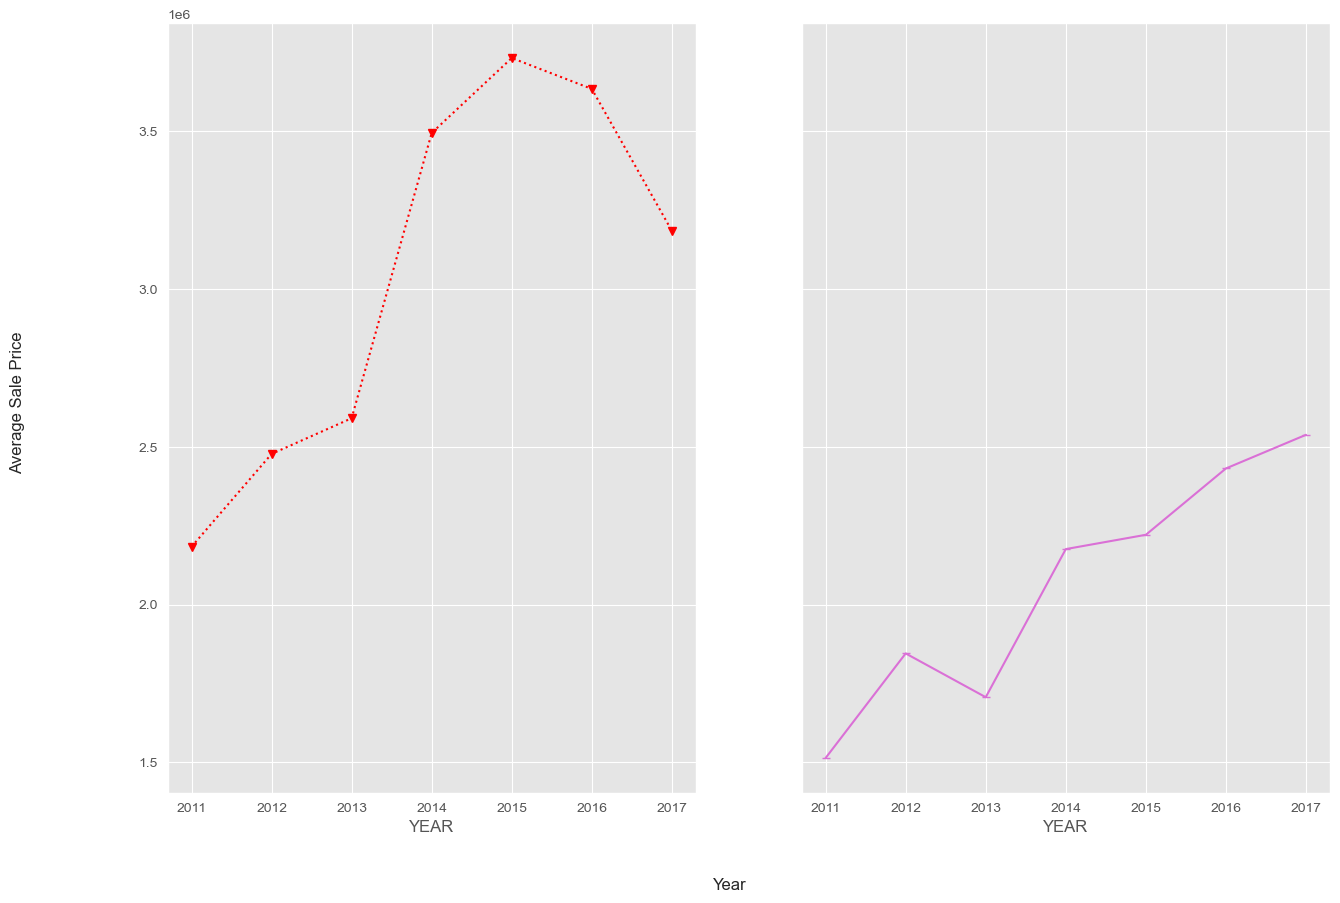

In [39]:
plt.style.use('ggplot')


fig, ax = plt.subplots(1,2, sharey= True, figsize = (15, 10))

df_zip.groupby('YEAR')['SALE PRICE'].mean().plot(marker='v',
                                                 color = 'red',
                                                 ls = ':',
                                                 ax = ax[0])

df_final.groupby('YEAR')['SALE PRICE'].mean().plot(marker='_',
                                                   color = 'orchid',
                                                   ax = ax[1])


fig.supxlabel("Year")
fig.supylabel("Average Sale Price")

#ax[0].set_xlabel("")
#ax[0].tick_params(axis="x", labelbottom=False)

# Week 6 Discussion (2/25)

## Exercise 4

In [40]:
import geopandas as gpd

In [41]:
df_outliers

,BOROUGH,NEIGHBORHOOD,BUILDING CLASS CATEGORY,TAX CLASS AT PRESENT,BLOCK,LOT,EASE-MENT,BUILDING CLASS AT PRESENT,ADDRESS,APARTMENT NUMBER,...,TOTAL UNITS,LAND SQUARE FEET,GROSS SQUARE FEET,YEAR BUILT,TAX CLASS AT TIME OF SALE,BUILDING CLASS AT TIME OF SALE,SALE PRICE,SALE DATE,YEAR,YEAR2
164,1,CHELSEA,08 RENTALS - ELEVATOR APARTMENTS,2,796,48,,D8,120 WEST 21ST STREET,,...,213,21344,174621,2000,2,D8,138988454,2011-08-25,2011,2011
950,1,CHELSEA,21 OFFICE BUILDINGS,4,713,1,,O9,75 NINTH AVENUE,,...,62,165200,1100533,1934,4,O9,795000000,2011-08-01,2011,2011
960,1,CHELSEA,23 LOFT BUILDINGS,4,672,1,,O9,601 WEST 26TH STREET,,...,208,124100,1835150,1931,4,L9,920000000,2011-07-29,2011,2011
1303,1,CIVIC CENTER,28 COMMERCIAL CONDOS,4,113,1001,,R5,375 PEARL STREET,PU,...,1,0,0,0,4,R5,120000000,2011-06-07,2011,2011
1590,1,CLINTON,28 COMMERCIAL CONDOS,4,1051,1107,,R5,450 W 42ND STREET,HOTEL,...,1,0,0,2008,4,R5,263000000,2011-06-01,2011,2011
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
155590,1,MURRAY HILL,21 OFFICE BUILDINGS,4,861,57,,O6,147-149 MADISON AVENUE,,...,49,6918,119006,1917,4,O6,87700000,2017-11-28,2017,2017
155598,1,MURRAY HILL,26 OTHER HOTELS,4,889,55,,HB,150 EAST 34TH STREET,,...,2,10399,176584,1987,4,HB,118000000,2017-06-20,2017,2017
156773,1,TRIBECA,43 CONDO OFFICE BUILDINGS,4,212,1301,,RB,50 VARICK STREET,UNT A,...,1,0,0,1960,4,RB,135000000,2017-08-07,2017,2017
161977,1,UPPER WEST SIDE (59-79),33 EDUCATIONAL FACILITIES,4,1118,14,,W4,15 WEST 65TH STREET,,...,1,28000,99875,1972,4,W4,147000000,2017-11-15,2017,2017


In [42]:
df_outliers.columns

Index(['BOROUGH', 'NEIGHBORHOOD', 'BUILDING CLASS CATEGORY',
       'TAX CLASS AT PRESENT', 'BLOCK', 'LOT', 'EASE-MENT',
       'BUILDING CLASS AT PRESENT', 'ADDRESS', 'APARTMENT NUMBER', 'ZIP CODE',
       'RESIDENTIAL UNITS', 'COMMERCIAL UNITS', 'TOTAL UNITS',
       'LAND SQUARE FEET', 'GROSS SQUARE FEET', 'YEAR BUILT',
       'TAX CLASS AT TIME OF SALE', 'BUILDING CLASS AT TIME OF SALE',
       'SALE PRICE', 'SALE DATE', 'YEAR', 'YEAR2'],
      dtype='object')

In [43]:
df_outliers['FullAddress'] = (df_outliers['ADDRESS'].astype(str).str.strip() + 
                              "," +
                              df_outliers['ZIP CODE'].astype(str).str.strip()
                             )

In [44]:
df_outliers.head()

,BOROUGH,NEIGHBORHOOD,BUILDING CLASS CATEGORY,TAX CLASS AT PRESENT,BLOCK,LOT,EASE-MENT,BUILDING CLASS AT PRESENT,ADDRESS,APARTMENT NUMBER,...,LAND SQUARE FEET,GROSS SQUARE FEET,YEAR BUILT,TAX CLASS AT TIME OF SALE,BUILDING CLASS AT TIME OF SALE,SALE PRICE,SALE DATE,YEAR,YEAR2,FullAddress
164,1,CHELSEA,08 RENTALS - ELEVATOR APARTMENTS,2,796,48,,D8,120 WEST 21ST STREET,,...,21344,174621,2000,2,D8,138988454,2011-08-25,2011,2011,"120 WEST 21ST STREET,10011"
950,1,CHELSEA,21 OFFICE BUILDINGS,4,713,1,,O9,75 NINTH AVENUE,,...,165200,1100533,1934,4,O9,795000000,2011-08-01,2011,2011,"75 NINTH AVENUE,10011"
960,1,CHELSEA,23 LOFT BUILDINGS,4,672,1,,O9,601 WEST 26TH STREET,,...,124100,1835150,1931,4,L9,920000000,2011-07-29,2011,2011,"601 WEST 26TH STREET,10001"
1303,1,CIVIC CENTER,28 COMMERCIAL CONDOS,4,113,1001,,R5,375 PEARL STREET,PU,...,0,0,0,4,R5,120000000,2011-06-07,2011,2011,"375 PEARL STREET,10038"
1590,1,CLINTON,28 COMMERCIAL CONDOS,4,1051,1107,,R5,450 W 42ND STREET,HOTEL,...,0,0,2008,4,R5,263000000,2011-06-01,2011,2011,"450 W 42ND STREET,10036"


In [68]:
import requests

def census_geocode(address, benchmark="Public_AR_Current", vintage="Current_Current"):
    url = "https://geocoding.geo.census.gov/geocoder/locations/onelineaddress"
    params = {
        "address": address,
        "benchmark": benchmark,
        "vintage": vintage,
        "format": "json"
    }

    r = requests.get(url, params=params, timeout=60)
    r.raise_for_status() 

    data = r.json()
    matches = data["result"]["addressMatches"]
    if not matches:
        return None, None

    coords = matches[0]["coordinates"]
    return coords["y"], coords["x"]  # lat, lon

In [69]:
lat, lon = census_geocode("120 WEST 21ST STREET,10011")
print(lat, lon)

40.741825403438 -73.994393309342


In [73]:
df_outliers[["lat", "lon"]] = df_outliers["FullAddress"].apply(
    lambda x: pd.Series(census_geocode(x))
)

In [74]:
df_outliers.shape

(467, 26)

In [75]:
df_geo = df_outliers.dropna(subset = ['lat', 'lon'])

In [76]:
df_geo = gpd.GeoDataFrame(
    df_outliers,
    geometry = gpd.points_from_xy(df_outliers.lon, df_outliers.lat),
    crs= "EPSG:4326"
)

<Axes: >

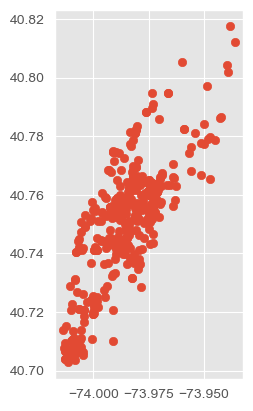

In [77]:
df_geo.plot()

In [81]:
nyct = gpd.read_file('nyct2020')

In [82]:
nyct.head()

,CTLabel,BoroCode,BoroName,CT2020,BoroCT2020,CDEligibil,NTAName,NTA2020,CDTA2020,CDTANAME,...,TotalUni_1,SinglehE,SinglehM,TotalHouse,TotalHou_1,MedHvalueE,MedHvalueM,MedHvalue2,MedHvalu_1,geometry
0,1,1,Manhattan,000100,1000100,I,The Battery-Governors Island-Ellis Island-Libe...,MN0191,MN01,MN01 Financial District-Tribeca (CD 1 Equivalent),...,12,0,12,0,12,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((972081.788 190733.467, 972184...."
1,14.01,1,Manhattan,001401,1001401,I,Lower East Side,MN0302,MN03,MN03 Lower East Side-Chinatown (CD 3 Equivalent),...,219,29,26,1711,219,1.077232e+09,192344868.0,809500.0,68025.0,"POLYGON ((987475.016 200297.218, 987705.443 20..."
2,14.02,1,Manhattan,001402,1001402,E,Lower East Side,MN0302,MN03,MN03 Lower East Side-Chinatown (CD 3 Equivalent),...,150,25,36,1620,150,NaN,NaN,NaN,NaN,"POLYGON ((988387.669 201258.312, 988621.002 20..."
3,18,1,Manhattan,001800,1001800,I,Lower East Side,MN0302,MN03,MN03 Lower East Side-Chinatown (CD 3 Equivalent),...,462,28,40,3383,462,2.010080e+08,123815587.0,719700.0,355899.0,"POLYGON ((987062.275 201781.687, 987099.571 20..."
4,22.01,1,Manhattan,002201,1002201,E,Lower East Side,MN0302,MN03,MN03 Lower East Side-Chinatown (CD 3 Equivalent),...,269,0,17,3165,269,NaN,NaN,NaN,NaN,"POLYGON ((990139.804 201568.505, 990129.867 20..."


In [83]:
manhattan = nyct[nyct['BoroName'] == 'Manhattan']

In [84]:
manhattan = manhattan.to_crs('EPSG: 4326')

Text(0.5, 1.0, 'Outlying Sale Price Data- Manhattan')

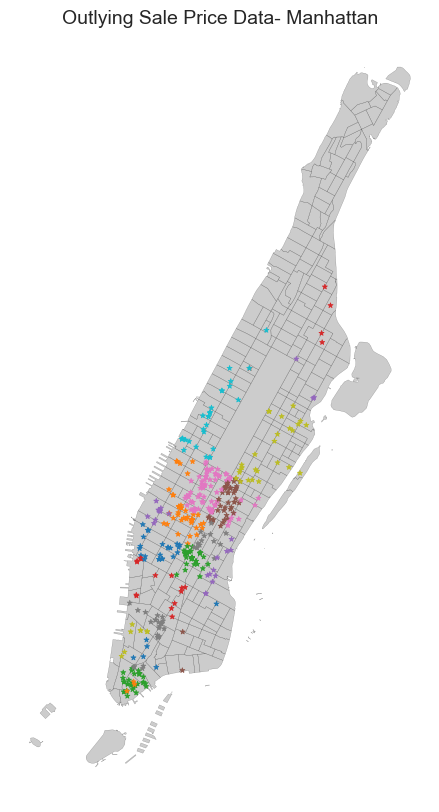

In [85]:
fig, ax= plt.subplots(1,1, figsize = (10,10))
sns.set_style('whitegrid')

manhattan.plot(ax=ax,
              alpha = 0.4,
              color = 'gray',
              edgecolor = 'k',
              linewidth = 0.2)

df_geo.plot(ax=ax,
           markersize = 15,
           marker = '*',
           column = 'NEIGHBORHOOD',)

ax.set_axis_off()
ax.set_title('Outlying Sale Price Data- Manhattan', fontsize = 14)

## Exercise 5 
### Running regressions 

Try running a multivariate regression of your choice